In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

# 日本語フォント設定
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
def get_final_energy(logfile):
    """ORCAログファイルから最終エネルギーを抽出"""
    with open(logfile, "r") as f:
        lines = f.readlines()

    # 最後のFINAL SINGLE POINT ENERGYを取得
    for line in reversed(lines):
        if "FINAL SINGLE POINT ENERGY" in line:
            energy = float(line.split()[-1])
            return energy
    return None

In [7]:
# 各状態のエネルギーを取得（Hartree）
reactant_energy = get_final_energy("../backwardopt/backwardopt.log")
ts_energy = get_final_energy("../tsfreq/tsfreq.log")
product_energy = get_final_energy("../forwardopt/forwardopt.log")

print(f"Reactant Energy: {reactant_energy:.8f} Hartree")
print(f"TS Energy:       {ts_energy:.8f} Hartree")
print(f"Product Energy:  {product_energy:.8f} Hartree")

Reactant Energy: -399.10111122 Hartree
TS Energy:       -399.09157977 Hartree
Product Energy:  -399.10700622 Hartree


In [8]:
# ハートリーをkcal/molに変換し、反応物を基準にする
hartree_to_kcal = 627.509474

reactant_rel = 0.0
ts_rel = (ts_energy - reactant_energy) * hartree_to_kcal
product_rel = (product_energy - reactant_energy) * hartree_to_kcal

print(f"\n=== Relative Energies (kcal/mol) ===")
print(f"Reactant:  {reactant_rel:.2f} kcal/mol")
print(f"TS:        {ts_rel:.2f} kcal/mol")
print(f"Product:   {product_rel:.2f} kcal/mol")
print(f"\nActivation Energy (Forward):  {ts_rel:.2f} kcal/mol")
print(f"Reaction Energy:              {product_rel:.2f} kcal/mol")


=== Relative Energies (kcal/mol) ===
Reactant:  0.00 kcal/mol
TS:        5.98 kcal/mol
Product:   -3.70 kcal/mol

Activation Energy (Forward):  5.98 kcal/mol
Reaction Energy:              -3.70 kcal/mol


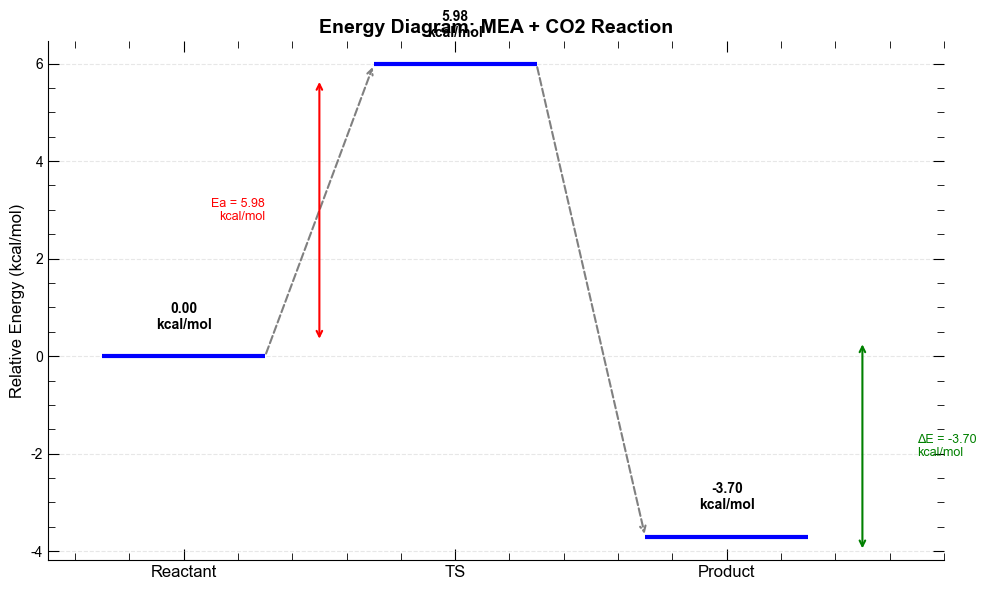


Energy diagram saved as energy_diagram.png


In [9]:
# エネルギーダイアグラムをプロット
fig, ax = plt.subplots(figsize=(10, 6))

# 各状態の位置
positions = [0, 1, 2]
energies = [reactant_rel, ts_rel, product_rel]
labels = ["Reactant", "TS", "Product"]

# 水平線を描画（各状態）
line_width = 0.3
for i, (pos, energy) in enumerate(zip(positions, energies)):
    ax.hlines(
        energy,
        pos - line_width,
        pos + line_width,
        colors="blue",
        linewidth=3,
        label=labels[i] if i == 0 else "",
    )

# 矢印で接続
# Reactant -> TS
ax.annotate(
    "",
    xy=(1 - line_width, ts_rel),
    xytext=(0 + line_width, reactant_rel),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="gray", linestyle="--"),
)

# TS -> Product
ax.annotate(
    "",
    xy=(2 - line_width, product_rel),
    xytext=(1 + line_width, ts_rel),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="gray", linestyle="--"),
)

# エネルギー値を表示
for pos, energy, label in zip(positions, energies, labels):
    ax.text(
        pos,
        energy + 0.5,
        f"{energy:.2f}\nkcal/mol",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# 活性化エネルギーを表示
ax.annotate(
    "",
    xy=(0.5, ts_rel - 0.3),
    xytext=(0.5, reactant_rel + 0.3),
    arrowprops=dict(arrowstyle="<->", lw=1.5, color="red"),
)
ax.text(
    0.3,
    (reactant_rel + ts_rel) / 2,
    f"Ea = {ts_rel:.2f}\nkcal/mol",
    ha="right",
    va="center",
    fontsize=9,
    color="red",
)

# 反応エネルギーを表示
ax.annotate(
    "",
    xy=(2.5, product_rel - 0.3),
    xytext=(2.5, reactant_rel + 0.3),
    arrowprops=dict(arrowstyle="<->", lw=1.5, color="green"),
)
ax.text(
    2.7,
    (reactant_rel + product_rel) / 2,
    f"ΔE = {product_rel:.2f}\nkcal/mol",
    ha="left",
    va="center",
    fontsize=9,
    color="green",
)

# 軸設定
ax.set_xlim(-0.5, 2.8)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Relative Energy (kcal/mol)", fontsize=12)
ax.set_title("Energy Diagram: MEA + CO2 Reaction", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("energy_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nEnergy diagram saved as energy_diagram.png")

In [10]:
# データをCSVに保存
import pandas as pd

data = {
    "State": ["Reactant", "TS", "Product"],
    "Energy (Hartree)": [reactant_energy, ts_energy, product_energy],
    "Relative Energy (kcal/mol)": [reactant_rel, ts_rel, product_rel],
}

df = pd.DataFrame(data)
df.to_csv("energy_summary.csv", index=False)
print("\nEnergy data saved to energy_summary.csv")
print(df)


Energy data saved to energy_summary.csv
      State  Energy (Hartree)  Relative Energy (kcal/mol)
0  Reactant       -399.101111                    0.000000
1        TS       -399.091580                    5.981074
2   Product       -399.107006                   -3.699171


In [14]:
# 電子エネルギーとギブスエネルギーの比較表
comparison_data = {
    "State": ["Reactant", "TS", "Product"],
    "Electronic E (kcal/mol)": [reactant_rel, ts_rel, product_rel],
    "Gibbs G (kcal/mol)": [reactant_gibbs_rel, ts_gibbs_rel, product_gibbs_rel],
}

df_comparison = pd.DataFrame(comparison_data)
print("\n=== Electronic Energy vs Gibbs Free Energy ===")
print(df_comparison.to_string(index=False))

# バリア高さと反応エネルギーの比較
print(f"\n=== Barrier and Reaction Energy Comparison ===")
print(f"{'':25s} {'Electronic':>12s} {'Gibbs':>12s} {'Difference':>12s}")
print(f"{'-'*63}")
print(
    f"{'Forward Barrier (Ea/ΔG‡)':25s} {ts_rel:12.2f} {ts_gibbs_rel:12.2f} {ts_gibbs_rel - ts_rel:12.2f}"
)
print(
    f"{'Reaction Energy (ΔE/ΔG)':25s} {product_rel:12.2f} {product_gibbs_rel:12.2f} {product_gibbs_rel - product_rel:12.2f}"
)


=== Electronic Energy vs Gibbs Free Energy ===
   State  Electronic E (kcal/mol)  Gibbs G (kcal/mol)
Reactant                 0.000000            0.000000
      TS                 5.981074            7.193311
 Product                -3.699171            1.717481

=== Barrier and Reaction Energy Comparison ===
                            Electronic        Gibbs   Difference
---------------------------------------------------------------
Forward Barrier (Ea/ΔG‡)          5.98         7.19         1.21
Reaction Energy (ΔE/ΔG)          -3.70         1.72         5.42


In [13]:
# 各状態のギブスの自由エネルギーを取得（Hartree）
# 注意: backwardoptは虚振動があるため、この値は参考値です
reactant_gibbs = get_gibbs_free_energy("../backwardopt_freq/backwardopt_freq.log")
ts_gibbs = get_gibbs_free_energy("../tsfreq/tsfreq.log")
product_gibbs = get_gibbs_free_energy("../forwardopt_freq/forwardopt_freq.log")

print(f"=== Gibbs Free Energy (298.15K) ===")
print(f"Reactant: {reactant_gibbs:.8f} Hartree")
print(f"TS:       {ts_gibbs:.8f} Hartree")
print(f"Product:  {product_gibbs:.8f} Hartree")

# 相対ギブスエネルギー (kcal/mol)
reactant_gibbs_rel = 0.0
ts_gibbs_rel = (ts_gibbs - reactant_gibbs) * hartree_to_kcal
product_gibbs_rel = (product_gibbs - reactant_gibbs) * hartree_to_kcal

print(f"\n=== Relative Gibbs Free Energy (kcal/mol) ===")
print(f"Reactant:  {reactant_gibbs_rel:.2f} kcal/mol")
print(f"TS:        {ts_gibbs_rel:.2f} kcal/mol")
print(f"Product:   {product_gibbs_rel:.2f} kcal/mol")
print(f"\nΔG‡ (Activation Free Energy):  {ts_gibbs_rel:.2f} kcal/mol")
print(f"ΔGrxn (Reaction Free Energy):  {product_gibbs_rel:.2f} kcal/mol")

print(f"\n⚠️  注意: Reactant (backwardopt) は虚振動を持つため、")
print(f"    このギブスエネルギーは正確ではありません。")

=== Gibbs Free Energy (298.15K) ===
Reactant: -399.02599046 Hartree
TS:       -399.01452719 Hartree
Product:  -399.02325348 Hartree

=== Relative Gibbs Free Energy (kcal/mol) ===
Reactant:  0.00 kcal/mol
TS:        7.19 kcal/mol
Product:   1.72 kcal/mol

ΔG‡ (Activation Free Energy):  7.19 kcal/mol
ΔGrxn (Reaction Free Energy):  1.72 kcal/mol

⚠️  注意: Reactant (backwardopt) は虚振動を持つため、
    このギブスエネルギーは正確ではありません。


In [12]:
def get_gibbs_free_energy(logfile):
    """ORCAログファイルからギブスの自由エネルギーを抽出"""
    with open(logfile, "r") as f:
        lines = f.readlines()

    # Final Gibbs free energyを検索
    for line in reversed(lines):
        if "Final Gibbs free energy" in line:
            gibbs_energy = float(line.split()[-2])  # "... -XXX.XXXXXXXX Eh"
            return gibbs_energy
    return None

In [17]:
# 電子エネルギー、E+ZPE、ギブスエネルギーの総合比較
comprehensive_data = {
    "State": ["Reactant", "TS", "Product"],
    "Electronic E (kcal/mol)": [reactant_rel, ts_rel, product_rel],
    "E + ZPE (0K, kcal/mol)": [reactant_zpe_rel, ts_zpe_rel, product_zpe_rel],
    "Gibbs G (298K, kcal/mol)": [reactant_gibbs_rel, ts_gibbs_rel, product_gibbs_rel],
}

df_comprehensive = pd.DataFrame(comprehensive_data)
print("\n=== Comprehensive Energy Comparison ===")
print(df_comprehensive.to_string(index=False))

# バリア高さと反応エネルギーの総合比較
print(f"\n=== Barrier and Reaction Energy (All Levels) ===")
print(f"{'':30s} {'Electronic':>12s} {'E+ZPE(0K)':>12s} {'Gibbs(298K)':>12s}")
print(f"{'-'*68}")
print(f"{'Forward Barrier':30s} {ts_rel:12.2f} {ts_zpe_rel:12.2f} {ts_gibbs_rel:12.2f}")
print(
    f"{'Reaction Energy':30s} {product_rel:12.2f} {product_zpe_rel:12.2f} {product_gibbs_rel:12.2f}"
)
print(
    f"\n{'Reverse Barrier':30s} {-product_rel + ts_rel:12.2f} {-product_zpe_rel + ts_zpe_rel:12.2f} {-product_gibbs_rel + ts_gibbs_rel:12.2f}"
)


=== Comprehensive Energy Comparison ===
   State  Electronic E (kcal/mol)  E + ZPE (0K, kcal/mol)  Gibbs G (298K, kcal/mol)
Reactant                 0.000000                0.000000                  0.000000
      TS                 5.981074                6.393925                  7.193311
 Product                -3.699171               -0.168596                  1.717481

=== Barrier and Reaction Energy (All Levels) ===
                                 Electronic    E+ZPE(0K)  Gibbs(298K)
--------------------------------------------------------------------
Forward Barrier                        5.98         6.39         7.19
Reaction Energy                       -3.70        -0.17         1.72

Reverse Barrier                        9.68         6.56         5.48


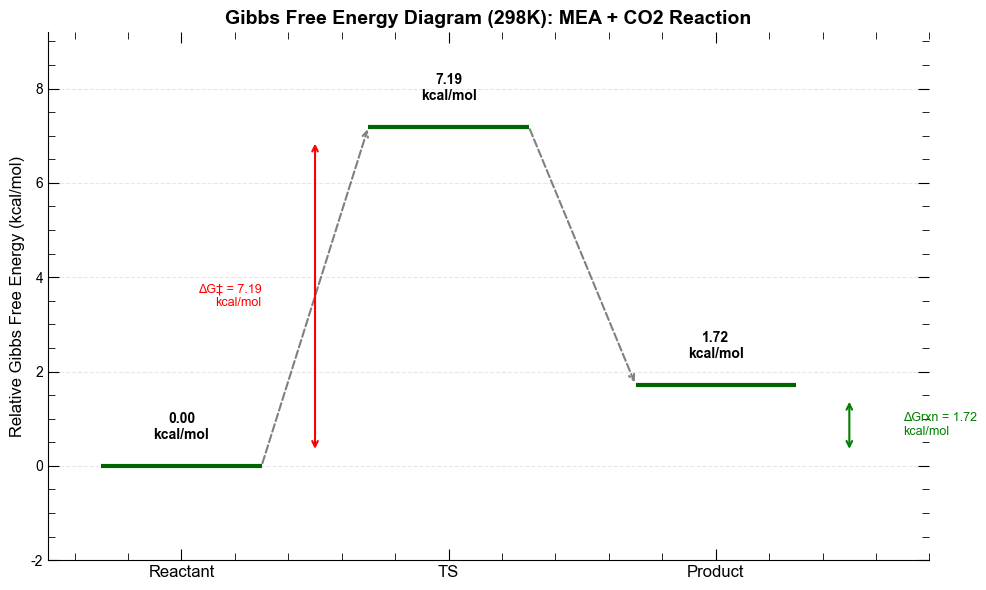


Gibbs free energy diagram saved as energy_diagram_gibbs.png
⚠️  Note: Reactant values based on structure with imaginary frequency


In [18]:
# ギブスの自由エネルギーダイアグラムをプロット
fig_gibbs, ax_gibbs = plt.subplots(figsize=(10, 6))

# 各状態の位置
positions_gibbs = [0, 1, 2]
energies_gibbs = [reactant_gibbs_rel, ts_gibbs_rel, product_gibbs_rel]
labels_gibbs = ["Reactant", "TS", "Product"]

# 水平線を描画（各状態）
line_width_gibbs = 0.3
for i, (pos, energy) in enumerate(zip(positions_gibbs, energies_gibbs)):
    ax_gibbs.hlines(
        energy,
        pos - line_width_gibbs,
        pos + line_width_gibbs,
        colors="darkgreen",
        linewidth=3,
        label=labels_gibbs[i] if i == 0 else "",
    )

# 矢印で接続
# Reactant -> TS
ax_gibbs.annotate(
    "",
    xy=(1 - line_width_gibbs, ts_gibbs_rel),
    xytext=(0 + line_width_gibbs, reactant_gibbs_rel),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="gray", linestyle="--"),
)

# TS -> Product
ax_gibbs.annotate(
    "",
    xy=(2 - line_width_gibbs, product_gibbs_rel),
    xytext=(1 + line_width_gibbs, ts_gibbs_rel),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="gray", linestyle="--"),
)

# エネルギー値を表示
for pos, energy, label in zip(positions_gibbs, energies_gibbs, labels_gibbs):
    ax_gibbs.text(
        pos,
        energy + 0.5,
        f"{energy:.2f}\nkcal/mol",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# 活性化自由エネルギーを表示（ΔG‡）
ax_gibbs.annotate(
    "",
    xy=(0.5, ts_gibbs_rel - 0.3),
    xytext=(0.5, reactant_gibbs_rel + 0.3),
    arrowprops=dict(arrowstyle="<->", lw=1.5, color="red"),
)
ax_gibbs.text(
    0.3,
    (reactant_gibbs_rel + ts_gibbs_rel) / 2,
    f"ΔG‡ = {ts_gibbs_rel:.2f}\nkcal/mol",
    ha="right",
    va="center",
    fontsize=9,
    color="red",
)

# 反応自由エネルギーを表示（ΔGrxn）
if product_gibbs_rel > 0:
    # 吸熱反応の場合
    ax_gibbs.annotate(
        "",
        xy=(2.5, product_gibbs_rel - 0.3),
        xytext=(2.5, reactant_gibbs_rel + 0.3),
        arrowprops=dict(arrowstyle="<->", lw=1.5, color="green"),
    )
    ax_gibbs.text(
        2.7,
        (reactant_gibbs_rel + product_gibbs_rel) / 2,
        f"ΔGrxn = {product_gibbs_rel:.2f}\nkcal/mol",
        ha="left",
        va="center",
        fontsize=9,
        color="green",
    )
else:
    # 発熱反応の場合
    ax_gibbs.annotate(
        "",
        xy=(2.5, product_gibbs_rel + 0.3),
        xytext=(2.5, reactant_gibbs_rel - 0.3),
        arrowprops=dict(arrowstyle="<->", lw=1.5, color="green"),
    )
    ax_gibbs.text(
        2.7,
        (reactant_gibbs_rel + product_gibbs_rel) / 2,
        f"ΔGrxn = {product_gibbs_rel:.2f}\nkcal/mol",
        ha="left",
        va="center",
        fontsize=9,
        color="green",
    )

# 軸設定
ax_gibbs.set_xlim(-0.5, 2.8)
ax_gibbs.set_xticks(positions_gibbs)
ax_gibbs.set_xticklabels(labels_gibbs, fontsize=12)
ax_gibbs.set_ylabel("Relative Gibbs Free Energy (kcal/mol)", fontsize=12)
ax_gibbs.set_title(
    "Gibbs Free Energy Diagram (298K): MEA + CO2 Reaction",
    fontsize=14,
    fontweight="bold",
)
ax_gibbs.grid(axis="y", alpha=0.3, linestyle="--")
ax_gibbs.spines["top"].set_visible(False)
ax_gibbs.spines["right"].set_visible(False)

# y軸範囲を適切に設定
y_min = min(energies_gibbs) - 2
y_max = max(energies_gibbs) + 2
ax_gibbs.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig("energy_diagram_gibbs.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nGibbs free energy diagram saved as energy_diagram_gibbs.png")
print(f"⚠️  Note: Reactant values based on structure with imaginary frequency")

In [16]:
# 各状態の零点エネルギーを取得（Hartree）
reactant_zpe = get_zero_point_energy("../backwardopt_freq/backwardopt_freq.log")
ts_zpe = get_zero_point_energy("../tsfreq/tsfreq.log")
product_zpe = get_zero_point_energy("../forwardopt_freq/forwardopt_freq.log")

print(f"=== Zero Point Energy ===")
print(f"Reactant: {reactant_zpe:.8f} Hartree")
print(f"TS:       {ts_zpe:.8f} Hartree")
print(f"Product:  {product_zpe:.8f} Hartree")

# 電子エネルギー + ZPE (0K)
reactant_E_plus_zpe = reactant_energy + reactant_zpe
ts_E_plus_zpe = ts_energy + ts_zpe
product_E_plus_zpe = product_energy + product_zpe

# 相対エネルギー (E + ZPE, 0K) (kcal/mol)
reactant_zpe_rel = 0.0
ts_zpe_rel = (ts_E_plus_zpe - reactant_E_plus_zpe) * hartree_to_kcal
product_zpe_rel = (product_E_plus_zpe - reactant_E_plus_zpe) * hartree_to_kcal

print(f"\n=== Relative Energy with ZPE (0K, kcal/mol) ===")
print(f"Reactant:  {reactant_zpe_rel:.2f} kcal/mol")
print(f"TS:        {ts_zpe_rel:.2f} kcal/mol")
print(f"Product:   {product_zpe_rel:.2f} kcal/mol")
print(f"\nΔE‡(0K) (Activation Energy with ZPE):  {ts_zpe_rel:.2f} kcal/mol")
print(f"ΔE(0K) (Reaction Energy with ZPE):     {product_zpe_rel:.2f} kcal/mol")

=== Zero Point Energy ===
Reactant: 0.11051223 Hartree
TS:       0.11117015 Hartree
Product:  0.11613856 Hartree

=== Relative Energy with ZPE (0K, kcal/mol) ===
Reactant:  0.00 kcal/mol
TS:        6.39 kcal/mol
Product:   -0.17 kcal/mol

ΔE‡(0K) (Activation Energy with ZPE):  6.39 kcal/mol
ΔE(0K) (Reaction Energy with ZPE):     -0.17 kcal/mol


In [15]:
def get_zero_point_energy(logfile):
    """ORCAログファイルから零点エネルギーを抽出"""
    with open(logfile, "r") as f:
        lines = f.readlines()

    # Zero point energyを検索
    for line in lines:
        if "Zero point energy" in line:
            zpe = float(line.split()[4])  # "... ... ... 0.XXXXXXXX Eh ..."
            return zpe
    return None

## TPSS0レベルでのギブスの自由エネルギー比較

周波数計算から熱力学補正（ギブスの自由エネルギー補正）を取得して比較します。